In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df = pd.read_csv(r"C:\Bita Drive\1. McMaster\Machine Learning\Project\archive\Final_data.csv")

# Exploratory Data Analysis #

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,38.851454,12.11458,18.0,28.17,39.865,49.63,59.67
Gender,20000,2,Female,10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight (kg),20000.0,NaN,NaN,NaN,73.898832,21.17301,39.18,58.16,70.0,86.1,130.77
Height (m),20000.0,NaN,NaN,NaN,1.723094,0.127033,1.49,1.62,1.71,1.8,2.01
Max_BPM,20000.0,NaN,NaN,NaN,179.889702,11.510805,159.31,170.0575,180.14,189.425,199.64
Avg_BPM,20000.0,NaN,NaN,NaN,143.704306,14.267688,119.07,131.22,142.99,156.06,169.84
Resting_BPM,20000.0,NaN,NaN,NaN,62.195813,7.289351,49.49,55.96,62.2,68.09,74.5
Session_Duration (hours),20000.0,NaN,NaN,NaN,1.259446,0.341336,0.49,1.05,1.27,1.46,2.02
Calories_Burned,20000.0,NaN,NaN,NaN,1280.109601,502.228982,323.11,910.8,1231.45,1553.1125,2890.82
Workout_Type,20000,4,Strength,5071,NaN,NaN,NaN,NaN,NaN,NaN,NaN


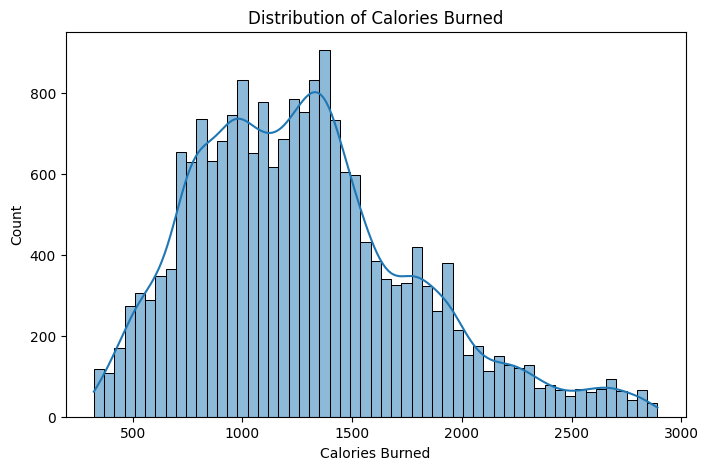

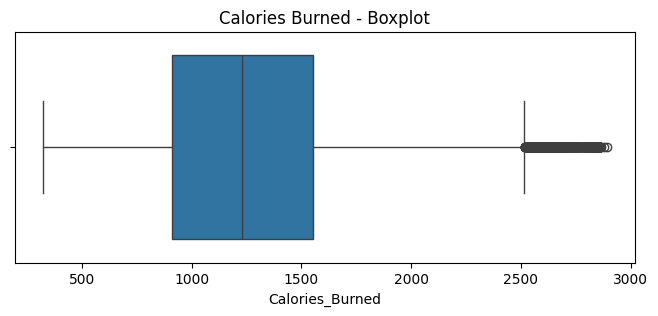

In [5]:
# ---------------------------------------------------------------------
# DISTRIBUTION OF TARGET (Calories_Burned)
# ---------------------------------------------------------------------

plt.figure(figsize=(8,5))
sns.histplot(df['Calories_Burned'], kde=True)
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Count")
plt.show()

# Boxplot for outlier inspection
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Calories_Burned'])
plt.title("Calories Burned - Boxplot")
plt.show()


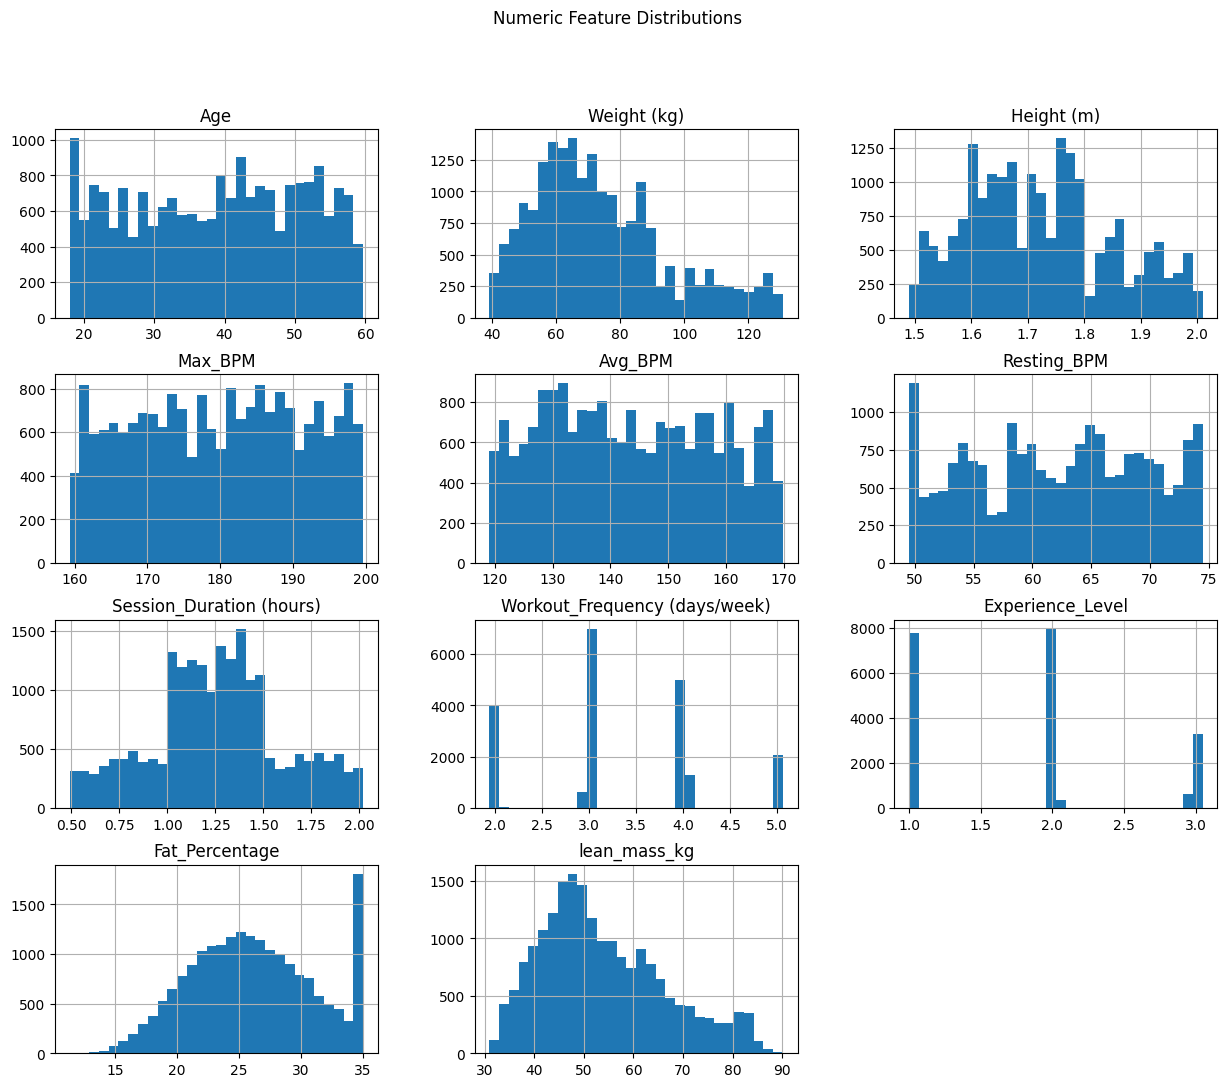

In [6]:
# ---------------------------------------------------------------------
# DISTRIBUTIONS OF KEY NUMERIC FEATURES
# ---------------------------------------------------------------------

numeric_cols = [
    'Age','Weight (kg)','Height (m)','Max_BPM','Avg_BPM','Resting_BPM',
    'Session_Duration (hours)','Workout_Frequency (days/week)',
    'Experience_Level','Fat_Percentage','lean_mass_kg'
]

df[numeric_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Numeric Feature Distributions")
plt.show()


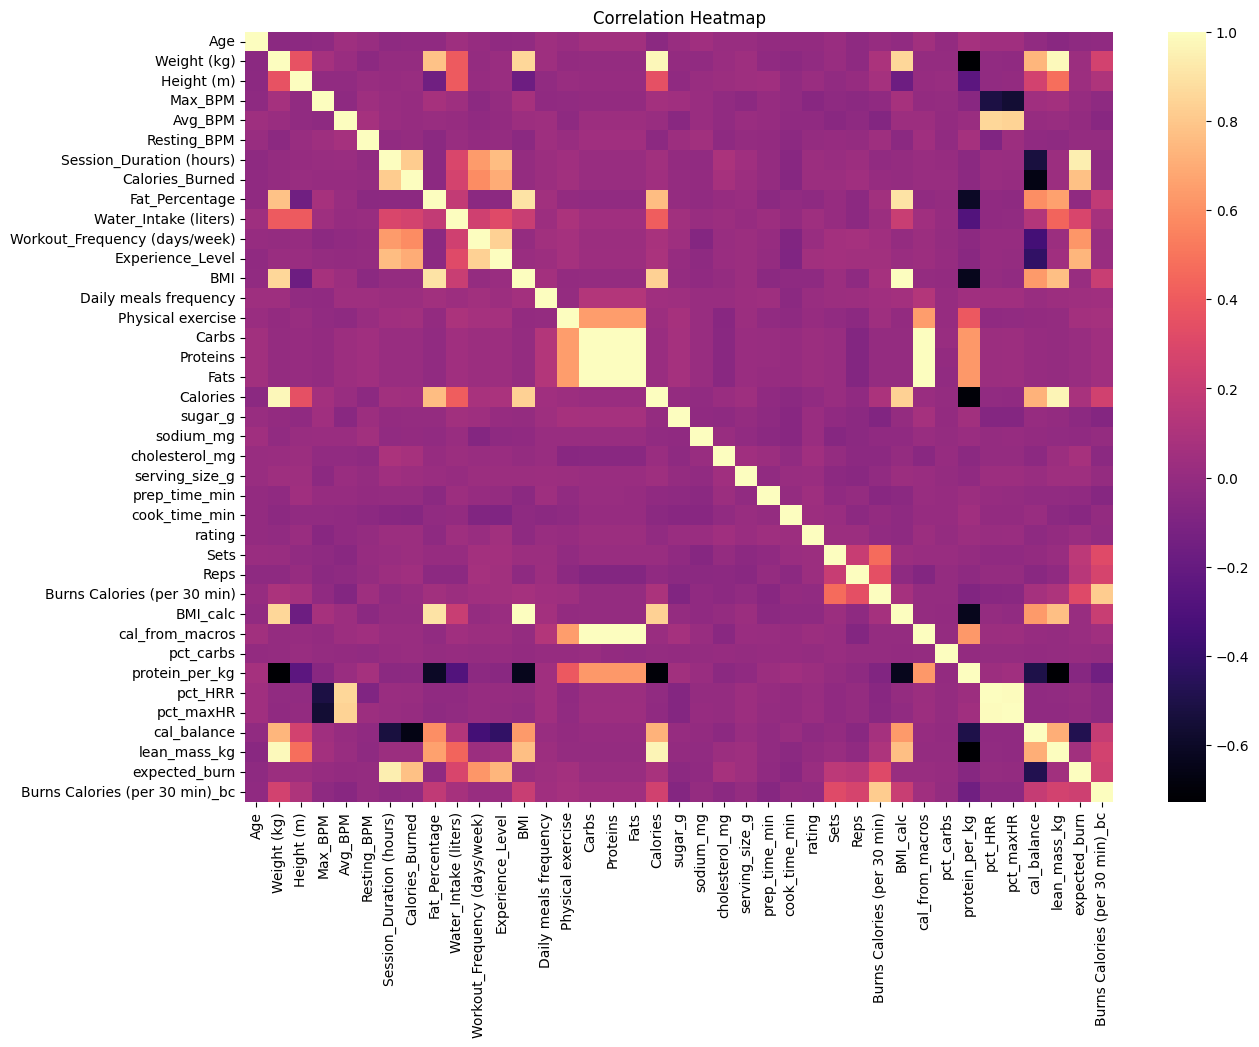

In [7]:
# ---------------------------------------------------------------------
# CORRELATION HEATMAP (NUMERIC ONLY)
# ---------------------------------------------------------------------

plt.figure(figsize=(14,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="magma", annot=False)
plt.title("Correlation Heatmap")
plt.show()


Top Correlations with Calories Burned:

Calories_Burned                  1.000000
Session_Duration (hours)         0.814368
expected_burn                    0.773932
Experience_Level                 0.697116
Workout_Frequency (days/week)    0.582787
Water_Intake (liters)            0.262731
cholesterol_mg                   0.072296
Physical exercise                0.049113
Calories                         0.047981
Reps                             0.043237
Name: Calories_Burned, dtype: float64


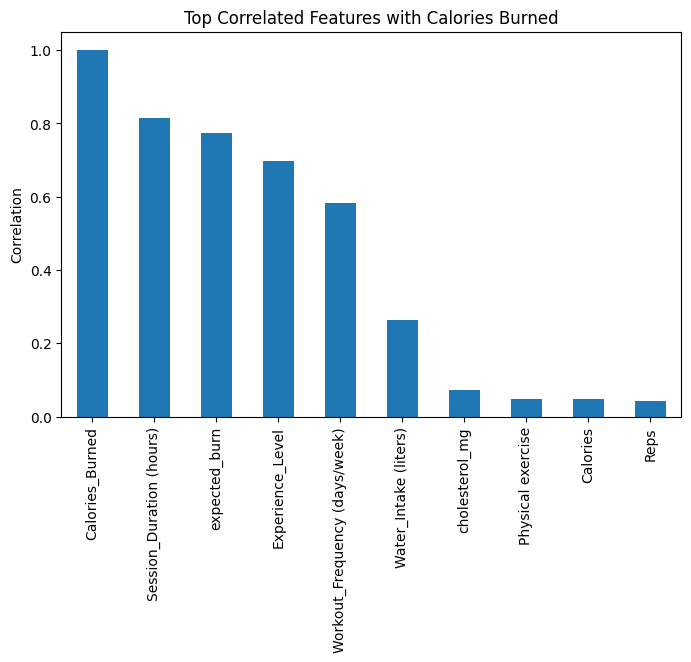

In [8]:
# ---------------------------------------------------------------------
# TOP CORRELATIONS WITH TARGET
# ---------------------------------------------------------------------

top_corr = corr['Calories_Burned'].sort_values(ascending=False)
print("Top Correlations with Calories Burned:\n")
print(top_corr.head(10))

plt.figure(figsize=(8,5))
top_corr.head(10).plot(kind='bar')
plt.title("Top Correlated Features with Calories Burned")
plt.ylabel("Correlation")
plt.show()


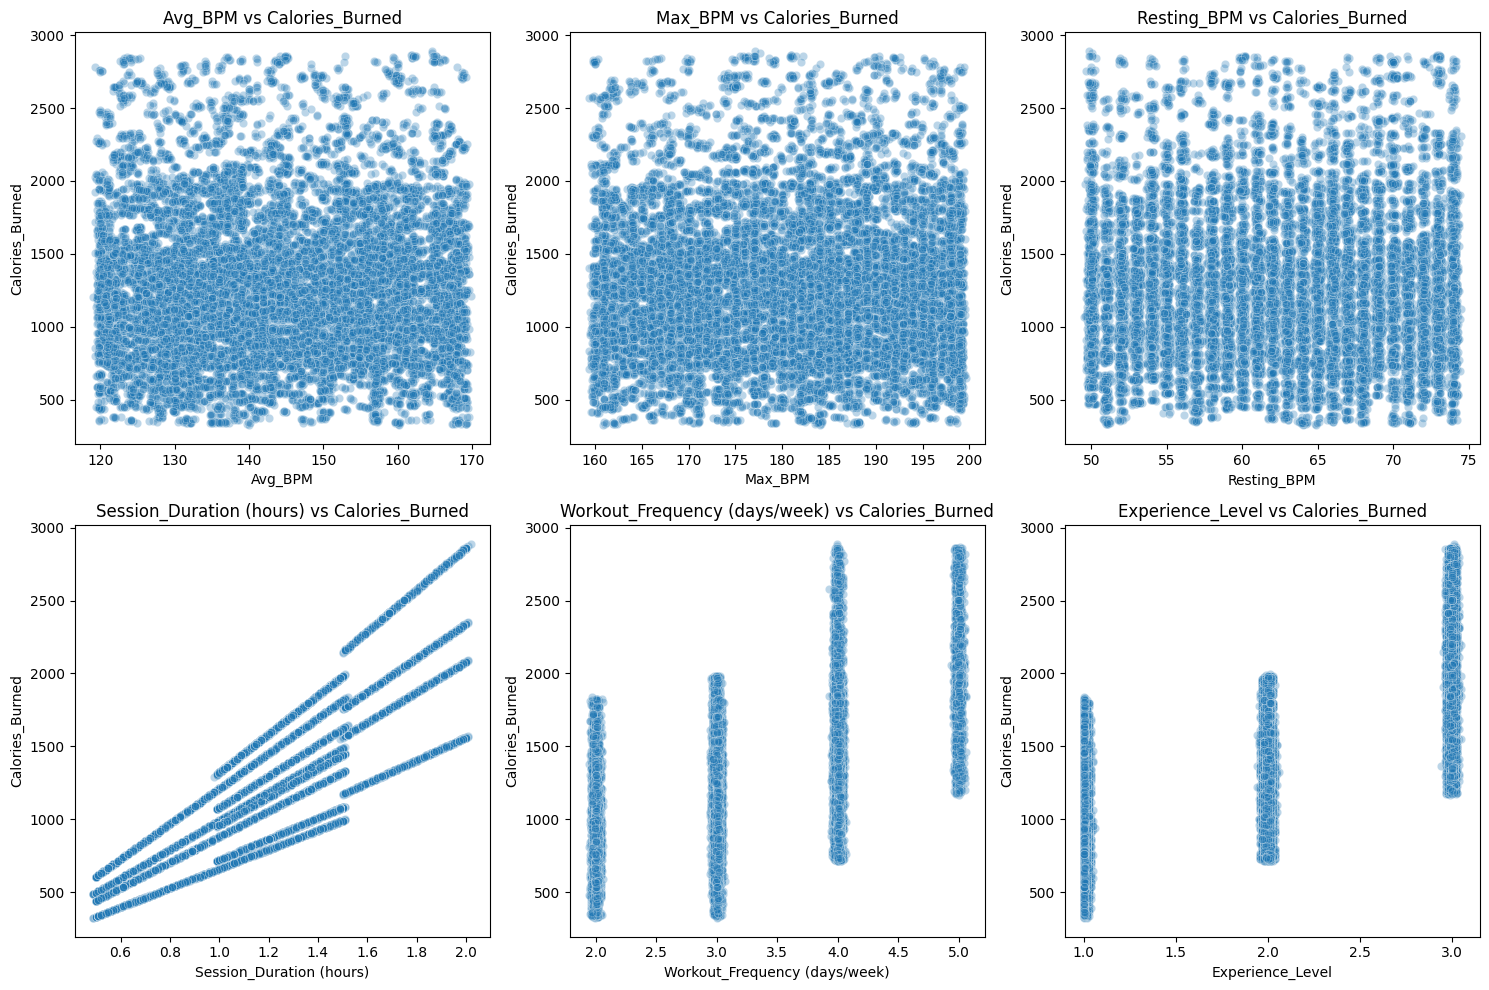

In [9]:
# ---------------------------------------------------------------------
# RELATIONSHIPS WITH TARGET (SCATTERPLOTS)
# ---------------------------------------------------------------------

features_to_plot = [
    'Avg_BPM','Max_BPM','Resting_BPM',
    'Session_Duration (hours)',
    'Workout_Frequency (days/week)',
    'Experience_Level'
]

plt.figure(figsize=(15,10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(data=df, x=col, y='Calories_Burned', alpha=0.3)
    plt.title(f"{col} vs Calories_Burned")

plt.tight_layout()
plt.show()


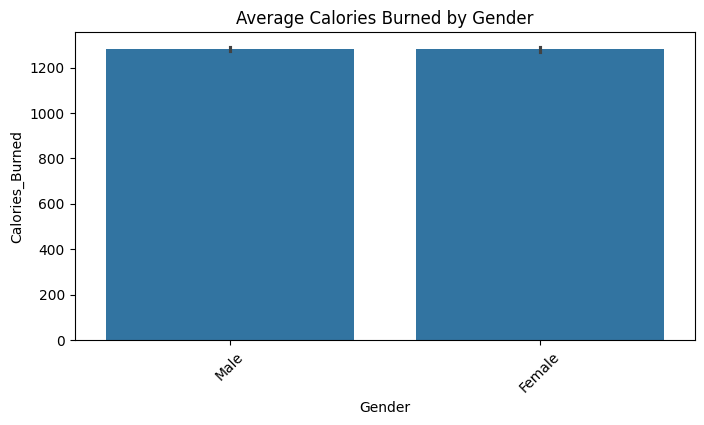

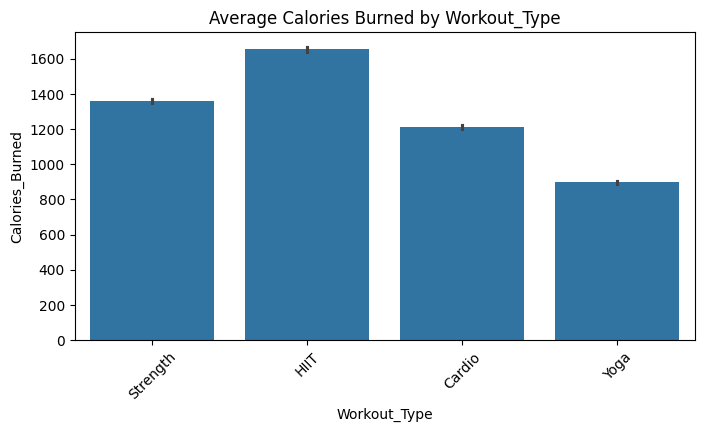

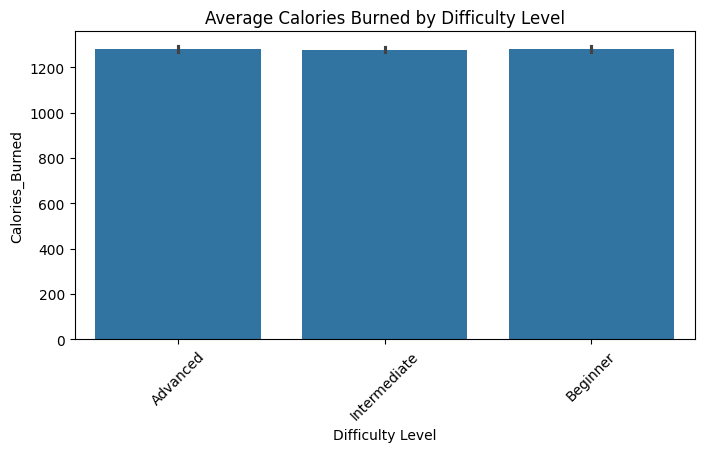

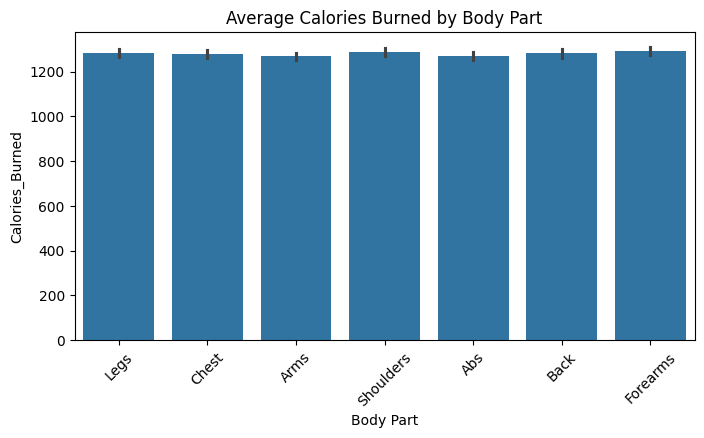

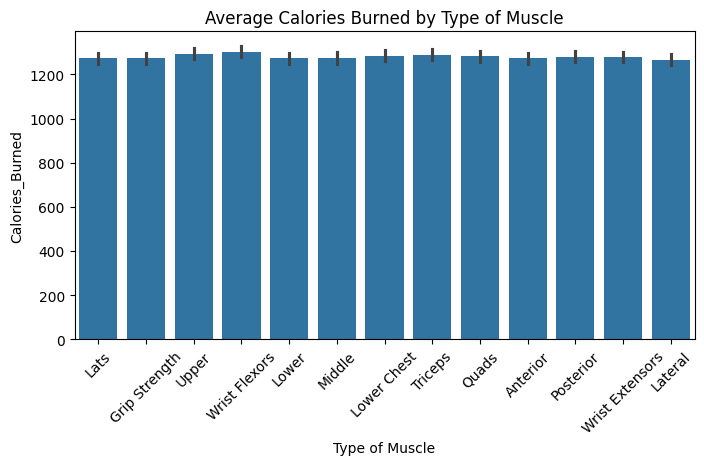

In [11]:
# ---------------------------------------------------------------------
# CATEGORICAL FEATURE EXPLORATION
# ---------------------------------------------------------------------

categorical_cols = ['Gender','Workout_Type','Difficulty Level','Body Part','Type of Muscle']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=col, y='Calories_Burned', data=df, estimator=np.mean)
    plt.title(f"Average Calories Burned by {col}")
    plt.xticks(rotation=45)
    plt.show()


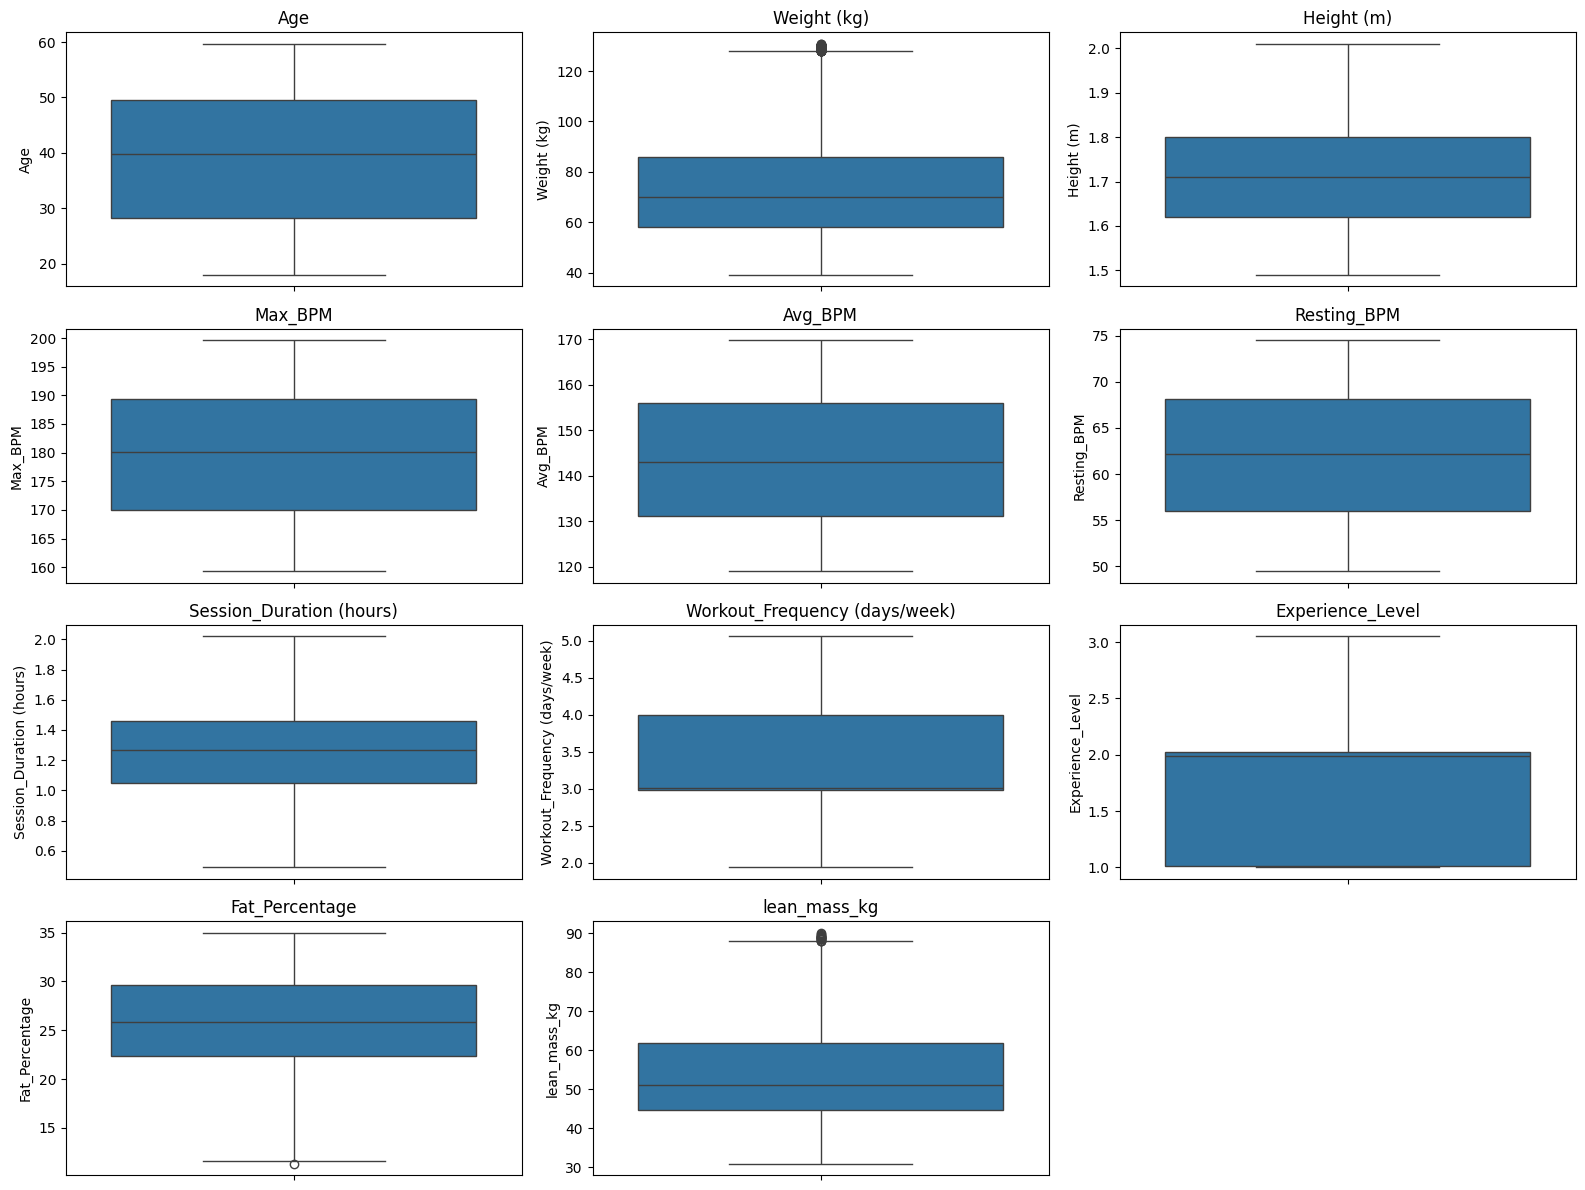

In [ ]:
# ---------------------------------------------------------------------
# BOX PLOTS FOR OUTLIERS IN NUMERIC FEATURES
# ---------------------------------------------------------------------

plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


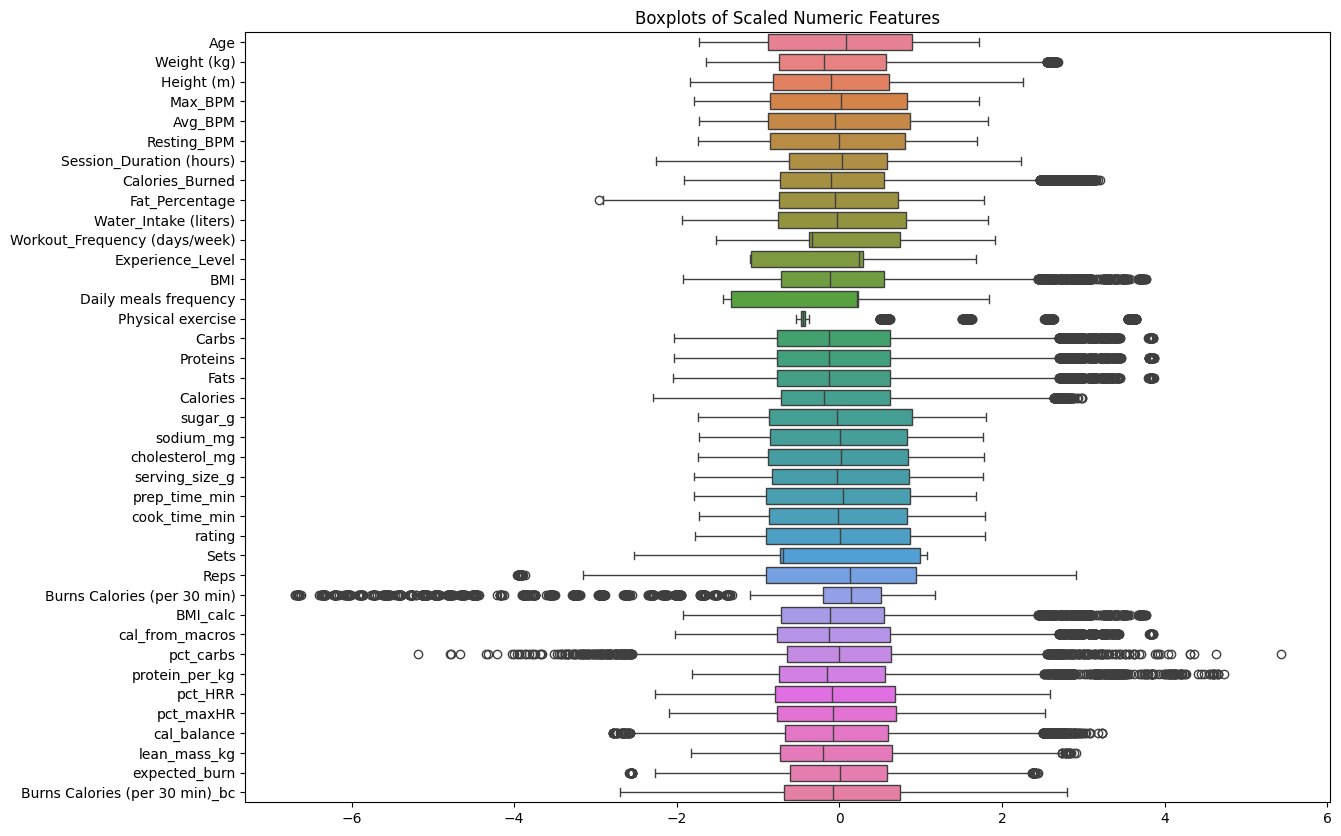

In [20]:
# ---------------------------------------------------------------------
# ALL-IN-ONE BOXPLOT FOR NUMERIC FEATURES (TO COMPARE THEM AND DETECT OUTLIERS)
# ---------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include='number').columns
scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

plt.figure(figsize=(14,10))
sns.boxplot(data=df_scaled[num_cols], orient='h')
plt.title("Boxplots of Scaled Numeric Features")
plt.show()


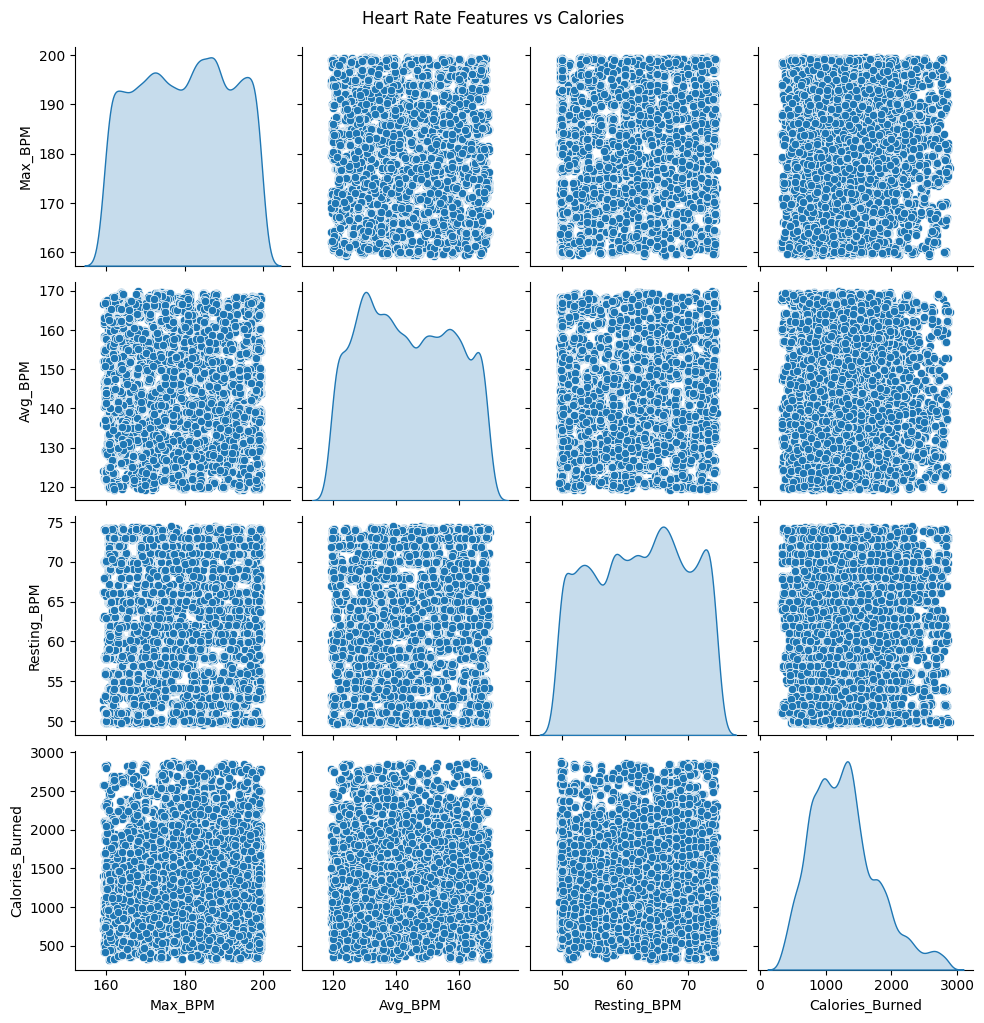

In [21]:
# ---------------------------------------------------------------------
# PAIRPLOT FOR HR-RELATED FEATURES
# ---------------------------------------------------------------------

hr_cols = ['Max_BPM','Avg_BPM','Resting_BPM','Calories_Burned']
sns.pairplot(df[hr_cols], diag_kind='kde')
plt.suptitle("Heart Rate Features vs Calories", y=1.02)
plt.show()


# Feature Engineering + Cleaning Dataset #

In [23]:
# ====================================================================
#   FULL CLEANING + FULL FEATURE ENGINEERING
#   Safe for ML training — no leakage, no noise, full engineered set
# ====================================================================

# Start from the ORIGINAL dataframe
df_full = df.copy()

# -----------------------------------------------------------
# 1. REMOVE COLUMNS THAT CAUSE STRICT DATA LEAKAGE
# -----------------------------------------------------------
leakage_cols = [
    'expected_burn',
    'Burns Calories (per 30 min)',
    'Burns Calories (per 30 min)_bc',
    'cal_balance',
    'cal_from_macros'
]

df_full.drop(columns=leakage_cols, inplace=True, errors='ignore')

# -----------------------------------------------------------
# 2. REMOVE VERY HIGH-CARDINALITY / NOISY CATEGORICAL COLUMNS
# -----------------------------------------------------------
noisy_cols = [
    'meal_name','meal_type','diet_type','cooking_method',
    'Name of Exercise','Benefit','Equipment Needed',
    'Body Part','Type of Muscle','Workout','Target Muscle Group'
]

df_full.drop(columns=noisy_cols, inplace=True, errors='ignore')

# -----------------------------------------------------------
# 3. FEATURE ENGINEERING
# -----------------------------------------------------------
df_fe = df_full.copy()

# ---------------------------
# Heart Rate Features
# ---------------------------
df_fe['HRR'] = df_fe['Max_BPM'] - df_fe['Resting_BPM']
df_fe['cardio_intensity'] = (df_fe['Avg_BPM'] - df_fe['Resting_BPM']) / df_fe['HRR']
df_fe['hr_spread'] = df_fe['Max_BPM'] - df_fe['Avg_BPM']
df_fe['session_load'] = df_fe['Avg_BPM'] * df_fe['Session_Duration (hours)']

# ---------------------------
# Anthropometric Features
# ---------------------------
df_fe['fat_mass'] = df_fe['Weight (kg)'] * df_fe['Fat_Percentage']
df_fe['FFMI'] = df_fe['lean_mass_kg'] / (df_fe['Height (m)'] ** 2)
df_fe['BSA'] = 0.007184 * ((df_fe['Height (m)']*100)**0.725) * (df_fe['Weight (kg)']**0.425)

# ---------------------------
# Exercise Features
# ---------------------------
df_fe['MET_est'] = df_fe['Avg_BPM'] / df_fe['Resting_BPM']
df_fe['workout_density'] = (df_fe['Sets'] * df_fe['Reps']) / df_fe['Session_Duration (hours)']
df_fe['strength_workload'] = df_fe['Sets'] * df_fe['Reps'] * df_fe['lean_mass_kg']

# ---------------------------
# Nutrition Features
# ---------------------------
df_fe['cal_density'] = df_fe['Calories'] / df_fe['serving_size_g']
df_fe['sugar_ratio'] = df_fe['sugar_g'] / (df_fe['Carbs'] + 1e-6)
df_fe['fat_protein_ratio'] = df_fe['Fats'] / (df_fe['Proteins'] + 1e-6)

# -----------------------------------------------------------
# 4. DEFINE TARGET AND FEATURES
# -----------------------------------------------------------
y = df_fe['Calories_Burned']
x = df_fe.drop(columns=['Calories_Burned', 'ID', 'Physical exercise', 'prep_time_min', 'cook_time_min', 'rating'], errors='ignore')

print("Shape of cleaned + engineered x:", x.shape)
x.head()


Shape of cleaned + engineered x: (20000, 46)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,...,session_load,fat_mass,FFMI,BSA,MET_est,workout_density,strength_workload,cal_density,sugar_ratio,fat_protein_ratio
0,34.91,Male,65.27,1.62,188.58,157.65,69.05,1.00,Strength,26.800377,...,157.6500,1749.260618,18.205073,1.696360,2.283128,104.340900,4985.136270,14.991284,0.118686,0.675436
1,23.37,Female,56.41,1.55,179.43,131.75,73.18,1.37,HIIT,27.655021,...,180.4975,1560.019732,16.986390,1.544127,1.800355,47.271168,2642.904036,14.448007,0.057577,0.667018
2,33.20,Female,58.98,1.67,175.04,123.95,54.96,0.91,Cardio,24.320821,...,112.7945,1434.442030,16.004726,1.661060,2.255277,120.329670,4887.595977,4.025737,0.173996,0.667414
3,38.69,Female,93.78,1.70,191.21,155.10,50.07,1.10,HIIT,32.813572,...,170.6100,3077.256762,21.801880,2.049220,3.097663,61.681091,4275.003881,8.453438,0.045960,0.674913
4,45.09,Male,52.42,1.88,193.58,152.88,70.84,1.08,Strength,17.307319,...,165.1104,907.249641,12.264459,1.721540,2.158103,69.351759,3246.723684,14.815561,0.071456,0.664637


# Integer Encoding #

In [24]:
x_encoded = x.copy()

# Identify remaining categorical columns in X_clean
categorical_cols = x_encoded.select_dtypes(include='object').columns.tolist()

# Apply integer encoding only to these remaining categorical columns
le = LabelEncoder()
for col in categorical_cols:
    x_encoded[col] = le.fit_transform(x_encoded[col])

# Verify encoding
x_encoded[categorical_cols].head()


,Gender,Workout_Type,Difficulty Level,Burns_Calories_Bin
0,1,2,0,2
1,0,1,2,0
2,0,0,2,0
3,0,1,0,0
4,1,2,0,1


In [25]:
x_encoded

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,...,session_load,fat_mass,FFMI,BSA,MET_est,workout_density,strength_workload,cal_density,sugar_ratio,fat_protein_ratio
0,34.91,1,65.27,1.62,188.58,157.65,69.05,1.00,2,26.800377,...,157.6500,1749.260618,18.205073,1.696360,2.283128,104.340900,4985.136270,14.991284,0.118686,0.675436
1,23.37,0,56.41,1.55,179.43,131.75,73.18,1.37,1,27.655021,...,180.4975,1560.019732,16.986390,1.544127,1.800355,47.271168,2642.904036,14.448007,0.057577,0.667018
2,33.20,0,58.98,1.67,175.04,123.95,54.96,0.91,0,24.320821,...,112.7945,1434.442030,16.004726,1.661060,2.255277,120.329670,4887.595977,4.025737,0.173996,0.667414
3,38.69,0,93.78,1.70,191.21,155.10,50.07,1.10,1,32.813572,...,170.6100,3077.256762,21.801880,2.049220,3.097663,61.681091,4275.003881,8.453438,0.045960,0.674913
4,45.09,1,52.42,1.88,193.58,152.88,70.84,1.08,2,17.307319,...,165.1104,907.249641,12.264459,1.721540,2.158103,69.351759,3246.723684,14.815561,0.071456,0.664637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,46.77,0,98.31,1.90,199.20,148.18,63.72,0.77,2,27.505498,...,114.0986,2704.065531,19.742201,2.266296,2.325487,111.076104,6095.567274,13.788579,0.140132,0.669863
19996,40.38,0,88.12,1.87,196.18,134.18,54.04,1.97,2,26.180562,...,264.3346,2307.031085,18.602102,2.138495,2.482976,58.695838,7521.747597,5.283590,0.214796,0.665184
19997,50.31,1,46.20,1.67,163.34,157.92,61.65,1.36,2,23.331802,...,214.7712,1077.929244,12.700602,1.497299,2.561557,55.617647,2679.222320,5.827982,0.059439,0.667181
19998,52.36,1,44.30,1.62,179.27,121.23,60.88,1.41,3,18.985868,...,170.9343,841.073969,13.675225,1.438753,1.991294,70.659787,3575.657771,3.172078,0.056962,0.655641


# Splitting Dataset #

In [26]:
# TRAIN TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=101)

# SCALE DATA
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

# Support Vector Machine - Regression #

In [27]:
# Use grid search for hyperparameter tuning
param_grid = {'C': [0.1, 1],                        ###<----- takes about 12 mins
              'kernel': ['linear', 'rbf', 'poly'],
              'gamma': ['scale', 'auto'],
              'degree': [2, 4],
              'epsilon': [0, 1]}

#param_grid = {'C': [0.01, 0.1, 1],                  ###<----- takes a lot longer than the simple combination (~3hrs)
              #'kernel': ['linear', 'rbf', 'poly'],
              #'gamma': ['scale', 'auto'],
              #'degree': [2, 3, 4],
              #'epsilon': [0, 0.1, 0.5, 1]}

svr = SVR()
grid = GridSearchCV(svr,param_grid=param_grid)

In [28]:
grid.fit(x_train,y_train)

,estimator,SVR()
,param_grid,"{'C': [0.1, 1], 'degree': [2, 4], 'epsilon': [0, 1], 'gamma': ['scale', 'auto'], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'linear'


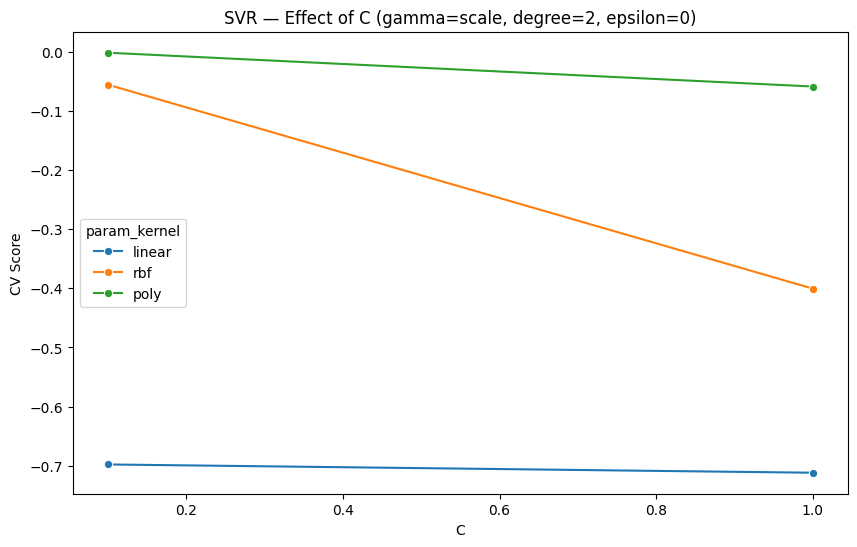

In [35]:
#Bita added-------------------------------------------------------
# Effect of C (x-axis), colored by kernel
#-----------------------------------------------------------------
cv_results = pd.DataFrame(grid.cv_results_)

# If you're using neg-MSE, convert to positive MSE
cv_results["score"] = -cv_results["mean_test_score"]


# Fix other hyperparameters to isolate C
subset = cv_results[
    (cv_results["param_gamma"] == "scale") &
    (cv_results["param_degree"] == 2) &
    (cv_results["param_epsilon"] == 0)
]

plt.figure(figsize=(10,6))
sns.lineplot(
    data=subset,
    x="param_C",
    y="score",
    hue="param_kernel",
    marker="o"
)
plt.title("SVR — Effect of C (gamma=scale, degree=2, epsilon=0)")
plt.xlabel("C")
plt.ylabel("CV Score")
plt.show()

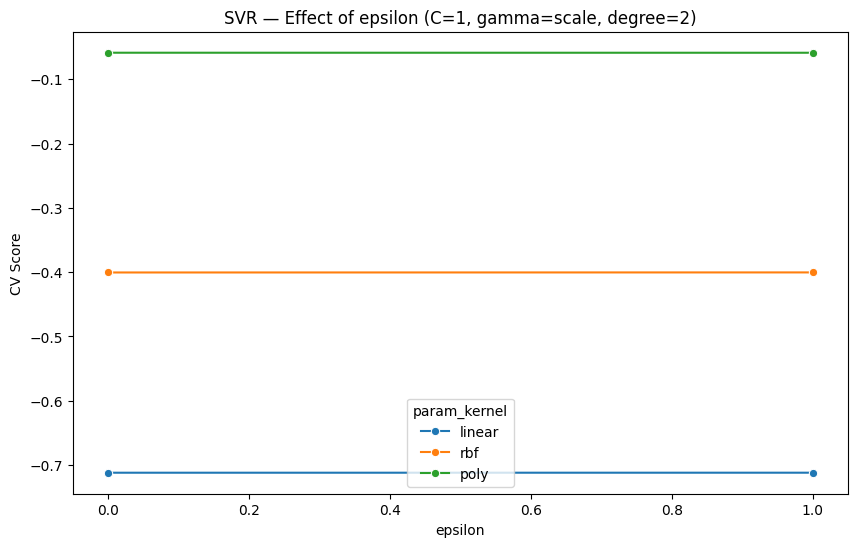

In [32]:
#Bita added-------------------------------------------------------
# Effect of epsilon, colored by kernel
#-----------------------------------------------------------------
subset = cv_results[
    (cv_results["param_gamma"] == "scale") &
    (cv_results["param_degree"] == 2) &
    (cv_results["param_C"] == 1)
]

plt.figure(figsize=(10,6))
sns.lineplot(
    data=subset,
    x="param_epsilon",
    y="score",
    hue="param_kernel",
    marker="o"
)
plt.title("SVR — Effect of epsilon (C=1, gamma=scale, degree=2)")
plt.xlabel("epsilon")
plt.ylabel("CV Score")
plt.show()


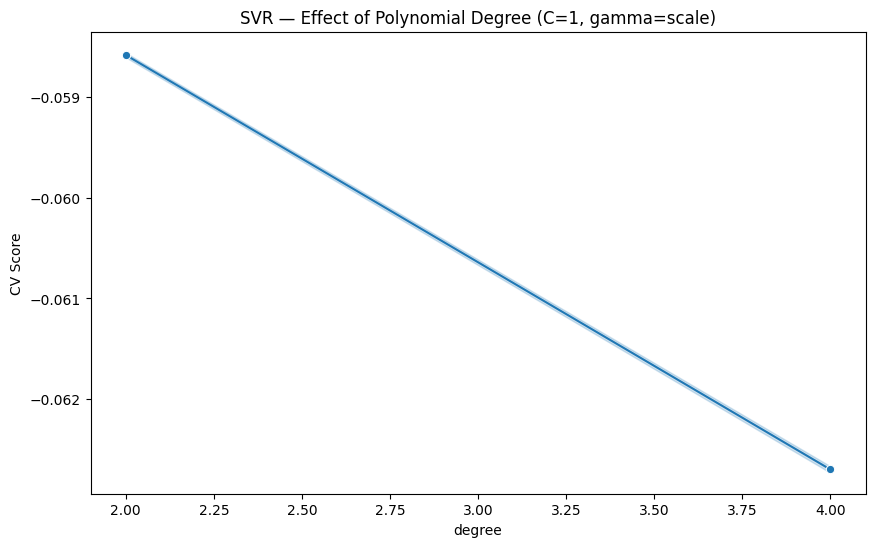

In [34]:
#Bita added-------------------------------------------------------
# Effect of degree (poly kernel only)
#-----------------------------------------------------------------
subset = cv_results[
    (cv_results["param_kernel"] == "poly") &
    (cv_results["param_C"] == 1) &
    (cv_results["param_gamma"] == "scale")
]

plt.figure(figsize=(10,6))
sns.lineplot(
    data=subset,
    x="param_degree",
    y="score",
    marker="o"
)
plt.title("SVR — Effect of Polynomial Degree (C=1, gamma=scale)")
plt.xlabel("degree")
plt.ylabel("CV Score")
plt.show()


In [36]:
grid.best_params_

{'C': 1, 'degree': 2, 'epsilon': 0, 'gamma': 'scale', 'kernel': 'linear'}

In [37]:
grid_preds = grid.predict(x_test)

In [38]:
print(mean_absolute_error(y_test,grid_preds))
print(np.sqrt(mean_squared_error(y_test,grid_preds)))

229.9697782517469
276.2815390260756


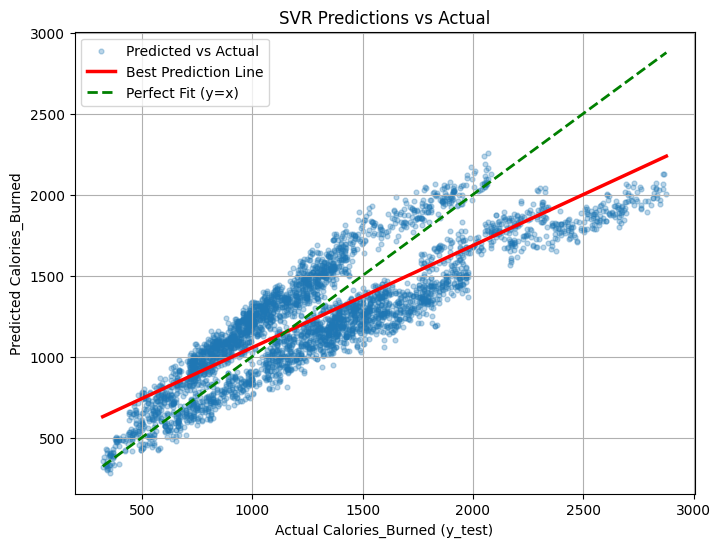

In [39]:
# --- Flatten in case they are pandas Series with index ---
y_true = np.array(y_test).ravel()
y_pred = np.array(grid_preds).ravel()

# --- Fit best prediction line ---
model_line = LinearRegression()
model_line.fit(y_true.reshape(1,-1).T, y_pred.reshape(1,-1).T)
line_x = np.linspace(min(y_true), max(y_true), 500)
line_y = model_line.predict(line_x.reshape(-1,1))

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3, label="Predicted vs Actual", s=12)
plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Best Prediction Line")
plt.plot(line_x, line_x, color="green", linestyle="--", linewidth=2, label="Perfect Fit (y=x)")

plt.xlabel("Actual Calories_Burned (y_test)")
plt.ylabel("Predicted Calories_Burned")
plt.title("SVR Predictions vs Actual")
plt.legend()
plt.grid(True)
plt.show()

#      Random Forest - Regression     #

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params (RF): {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV MAE (RF): 1.0006923931896199


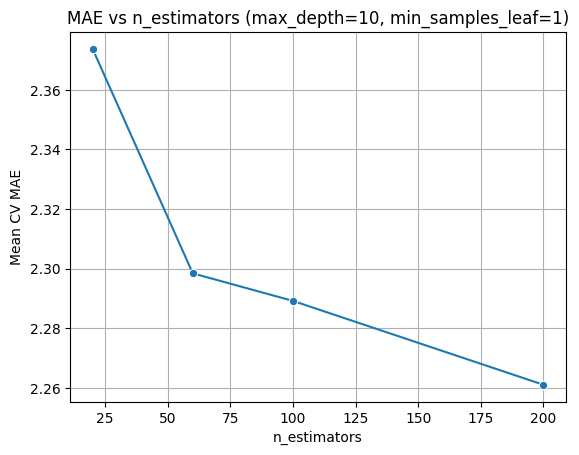

In [45]:
#---------------------------------------------------
# Bita added- 
# We’ll tune 3 core hyperparameters:
#       n_estimators – number of trees
#       max_depth – depth of each tree
#       min_samples_leaf – min samples in a leaf (regularization)
# to optimize MAE, so we use scoring="neg_mean_absolute_error"
#---------------------------------------------------
#1) Set up Random Forest + GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Base RF model
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Hyperparameter grid
rf_param_grid = {
    "n_estimators":    [20, 60, 100, 200],
    "max_depth":       [None, 5, 10, 20],
    "min_samples_leaf":[1, 2, 4],
}

# GridSearchCV – optimize MAE (note: negative because sklearn minimizes)
rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(x_train, y_train)

print("Best params (RF):", rf_grid.best_params_)
print("Best CV MAE (RF):", -rf_grid.best_score_)  # flip sign back

#2) Put all CV results into a DataFrame
cv_results = pd.DataFrame(rf_grid.cv_results_)

# Turn neg MAE into positive MAE for easier interpretation
cv_results["mean_MAE"] = -cv_results["mean_test_score"]
cv_results["std_MAE"]  =  cv_results["std_test_score"]

cv_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_MAE",
        "std_MAE",
        "rank_test_score"
    ]
].sort_values("rank_test_score").head(10)

#3) Line plot: effect of n_estimators
# Fix max_depth and min_samples_leaf and see how n_estimators affects MAE.
# Example: effect of n_estimators for fixed max_depth + min_samples_leaf
subset_n = cv_results[
    (cv_results["param_max_depth"] == 10) &
    (cv_results["param_min_samples_leaf"] == 1)
]

sns.lineplot(
    data=subset_n,
    x="param_n_estimators",
    y="mean_MAE",
    marker="o"
)
plt.title("MAE vs n_estimators (max_depth=10, min_samples_leaf=1)")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV MAE")
plt.grid(True)
plt.show()


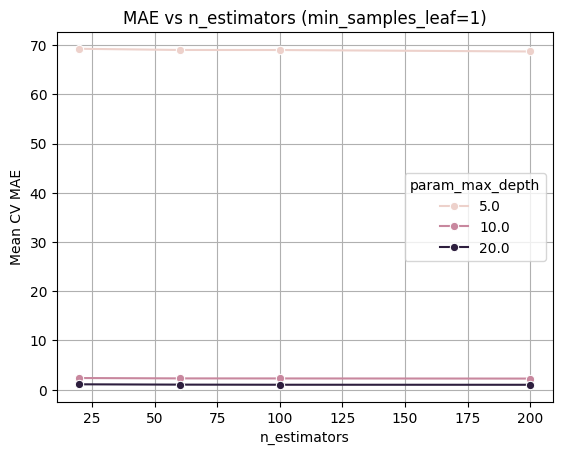

In [46]:
# different curves for different depths on the same plot
subset_n = cv_results[
    (cv_results["param_min_samples_leaf"] == 1)
]

sns.lineplot(
    data=subset_n,
    x="param_n_estimators",
    y="mean_MAE",
    hue="param_max_depth",
    marker="o"
)
plt.title("MAE vs n_estimators (min_samples_leaf=1)")
plt.xlabel("n_estimators")
plt.ylabel("Mean CV MAE")
plt.grid(True)
plt.show()


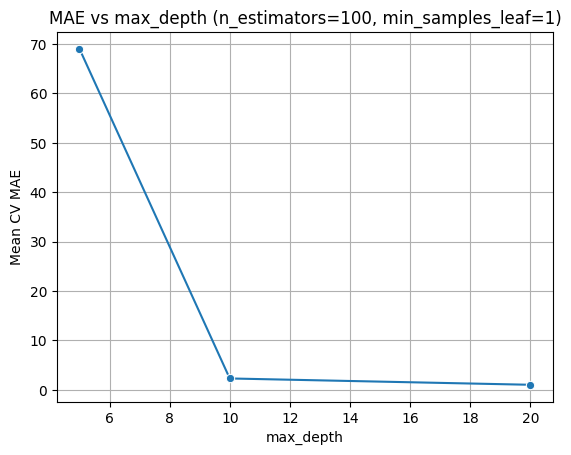

In [47]:
# Fix n_estimators and min_samples_leaf, vary max_depth
subset_depth = cv_results[
    (cv_results["param_n_estimators"] == 100) &
    (cv_results["param_min_samples_leaf"] == 1)
]

sns.lineplot(
    data=subset_depth,
    x="param_max_depth",
    y="mean_MAE",
    marker="o"
)
plt.title("MAE vs max_depth (n_estimators=100, min_samples_leaf=1)")
plt.xlabel("max_depth")
plt.ylabel("Mean CV MAE")
plt.grid(True)
plt.show()


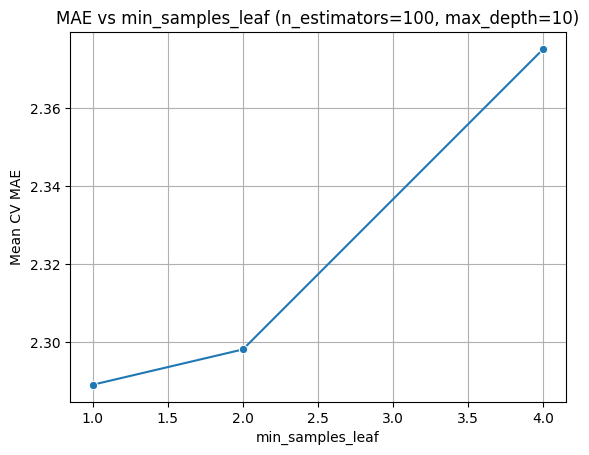

In [48]:
# effect of min_samples_leaf
# Fix n_estimators and max_depth, vary min_samples_leaf.
subset_leaf = cv_results[
    (cv_results["param_n_estimators"] == 100) &
    (cv_results["param_max_depth"] == 10)
]

sns.lineplot(
    data=subset_leaf,
    x="param_min_samples_leaf",
    y="mean_MAE",
    marker="o"
)
plt.title("MAE vs min_samples_leaf (n_estimators=100, max_depth=10)")
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean CV MAE")
plt.grid(True)
plt.show()


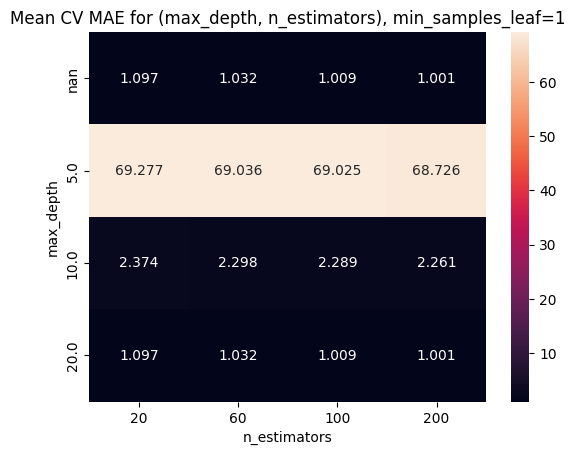

In [49]:
# MAE for combinations of n_estimators × max_depth (fix min_samples_leaf):
subset_heat = cv_results[
    (cv_results["param_min_samples_leaf"] == 1)
]

pivot = subset_heat.pivot(
    index="param_max_depth",
    columns="param_n_estimators",
    values="mean_MAE"
)

sns.heatmap(pivot, annot=True, fmt=".3f")
plt.title("Mean CV MAE for (max_depth, n_estimators), min_samples_leaf=1")
plt.xlabel("n_estimators")
plt.ylabel("max_depth")
plt.show()


In [40]:
trees = 60
RFmodel = RandomForestRegressor(n_estimators = trees)
RFmodel.fit(x_train, y_train)

,n_estimators,60
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
RFmodel_preds = RFmodel.predict(x_test)

In [42]:
print(mean_absolute_error(y_test,RFmodel_preds))
print(np.sqrt(mean_squared_error(y_test,RFmodel_preds)))

0.6601528333333543
1.1973583728821884


### This cell is used to test predictions ###

In [43]:
# --- Convert y_test to numpy array to avoid KeyError ---
y_test_np = np.array(y)

# --- Select one random index ---
rand_index = np.random.randint(0, len(x_test))

# --- Extract the sample ---
sample_x = x_test[rand_index]          # x_test is numpy → OK
sample_y_true = y_test_np[rand_index]  # now y_test is also numpy array

# --- Predict ---
sample_y_pred = RFmodel.predict([sample_x])[0]

print("=== Random Sample Prediction (Random Forest) ===")
print(f"Random index selected: {rand_index}")
print(f"Input features (x):\n{sample_x}")

print(f"\nTrue Calories_Burned:      {sample_y_true:.4f}")
print(f"Predicted Calories_Burned: {sample_y_pred:.4f}")
print(f"Absolute Error:            {abs(sample_y_true - sample_y_pred):.4f}")

=== Random Sample Prediction (Random Forest) ===
Random index selected: 1109
Input features (x):
[ 1.16685682 -0.99538565 -0.62533233 -0.73123432 -0.86249092 -1.39816968
  1.6275559  -2.07667349 -0.45978015 -0.84400335  1.30190773 -0.34845183
 -1.09736524 -0.31181794  0.2148778  -0.38782761 -0.37463891 -0.39385144
 -0.81583623 -1.47240183  1.58975599 -0.6893025  -0.5624153   0.95663927
 -0.64954332 -1.2288216  -0.3124224  -0.06649014  0.09852208 -1.25098428
 -0.77004069 -0.51263016  1.34301206 -1.62634316 -1.25098428  0.54200806
 -2.1487207  -0.74188759 -0.07571429 -0.74171874 -1.89407422  2.51002724
 -0.39823538 -0.3006016  -1.35585179 -0.70849282]

True Calories_Burned:      1738.1400
Predicted Calories_Burned: 664.5490
Absolute Error:            1073.5910


In [44]:
y[rand_index]

np.float64(1738.14)

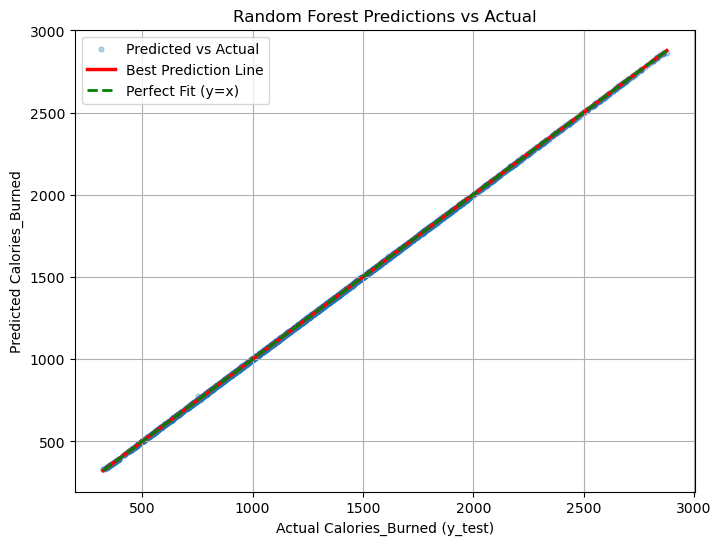

In [28]:
# --- Flatten in case they are pandas Series with index ---
y_true = np.array(y_test).ravel()
y_pred = np.array(RFmodel_preds).ravel()

# --- Fit best prediction line ---
model_line = LinearRegression()
model_line.fit(y_true.reshape(1,-1).T, y_pred.reshape(1,-1).T)
line_x = np.linspace(min(y_true), max(y_true), 500)
line_y = model_line.predict(line_x.reshape(-1,1))

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3, label="Predicted vs Actual", s=12)
plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Best Prediction Line")
plt.plot(line_x, line_x, color="green", linestyle="--", linewidth=2, label="Perfect Fit (y=x)")

plt.xlabel("Actual Calories_Burned (y_test)")
plt.ylabel("Predicted Calories_Burned")
plt.title("Random Forest Predictions vs Actual")
plt.legend()
plt.grid(True)
plt.show()

#        Ada Boost - Regression       #

In [29]:
ABmodel = AdaBoostRegressor(n_estimators = trees)
ABmodel.fit(x_train, y_train)

AdaBoostRegressor(n_estimators=60)

In [30]:
ABmodel_preds = ABmodel.predict(x_test)

In [31]:
print(mean_absolute_error(y_test,ABmodel_preds))
print(np.sqrt(mean_squared_error(y_test,ABmodel_preds)))

139.39575211758765
157.09806174491493


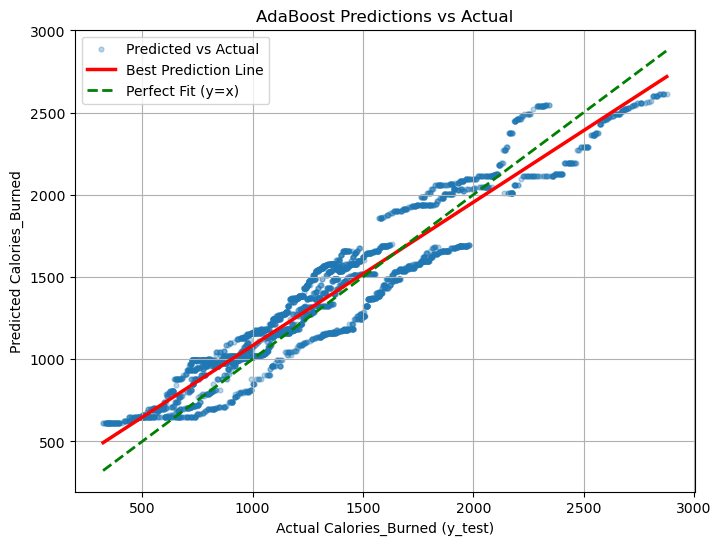

In [32]:
# --- Flatten in case they are pandas Series with index ---
y_true = np.array(y_test).ravel()
y_pred = np.array(ABmodel_preds).ravel()

# --- Fit best prediction line ---
model_line = LinearRegression()
model_line.fit(y_true.reshape(1,-1).T, y_pred.reshape(1,-1).T)
line_x = np.linspace(min(y_true), max(y_true), 500)
line_y = model_line.predict(line_x.reshape(-1,1))

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3, label="Predicted vs Actual", s=12)
plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Best Prediction Line")
plt.plot(line_x, line_x, color="green", linestyle="--", linewidth=2, label="Perfect Fit (y=x)")

plt.xlabel("Actual Calories_Burned (y_test)")
plt.ylabel("Predicted Calories_Burned")
plt.title("AdaBoost Predictions vs Actual")
plt.legend()
plt.grid(True)
plt.show()

#    Gradient Boosting - Regression   #

In [33]:
GBmodel = GradientBoostingRegressor(n_estimators = trees, learning_rate = 0.1)   ###<----- Grid search can be done here
GBmodel.fit(x_train, y_train)

GradientBoostingRegressor(n_estimators=60)

In [34]:
GBmodel_preds = GBmodel.predict(x_test)

In [35]:
print(mean_absolute_error(y_test,GBmodel_preds))
print(np.sqrt(mean_squared_error(y_test,GBmodel_preds)))

17.98037429451981
23.9870656994472


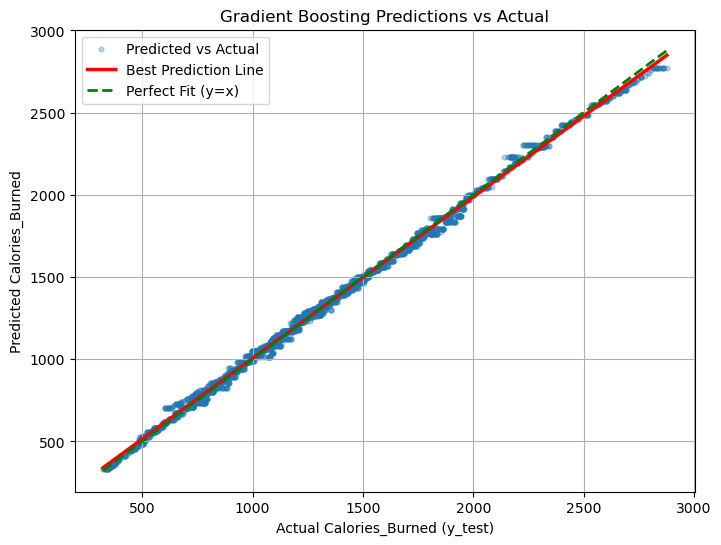

In [36]:
# --- Flatten in case they are pandas Series with index ---
y_true = np.array(y_test).ravel()
y_pred = np.array(GBmodel_preds).ravel()

# --- Fit best prediction line ---
model_line = LinearRegression()
model_line.fit(y_true.reshape(1,-1).T, y_pred.reshape(1,-1).T)
line_x = np.linspace(min(y_true), max(y_true), 500)
line_y = model_line.predict(line_x.reshape(-1,1))

# --- Plot ---
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.3, label="Predicted vs Actual", s=12)
plt.plot(line_x, line_y, color="red", linewidth=2.5, label="Best Prediction Line")
plt.plot(line_x, line_x, color="green", linestyle="--", linewidth=2, label="Perfect Fit (y=x)")

plt.xlabel("Actual Calories_Burned (y_test)")
plt.ylabel("Predicted Calories_Burned")
plt.title("Gradient Boosting Predictions vs Actual")
plt.legend()
plt.grid(True)
plt.show()

# GridSearch for Hyperparameter Tunning #

Random Forest Best Params: {'n_estimators': 150}
Random Forest MAE: 0.6444
Random Forest RMSE: 1.1665


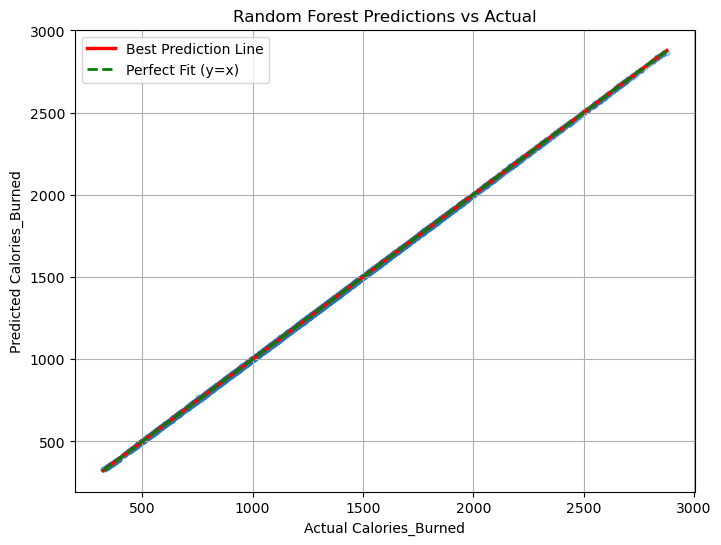

AdaBoost Best Params: {'learning_rate': 1, 'n_estimators': 50}
AdaBoost MAE: 139.4046
AdaBoost RMSE: 157.1556


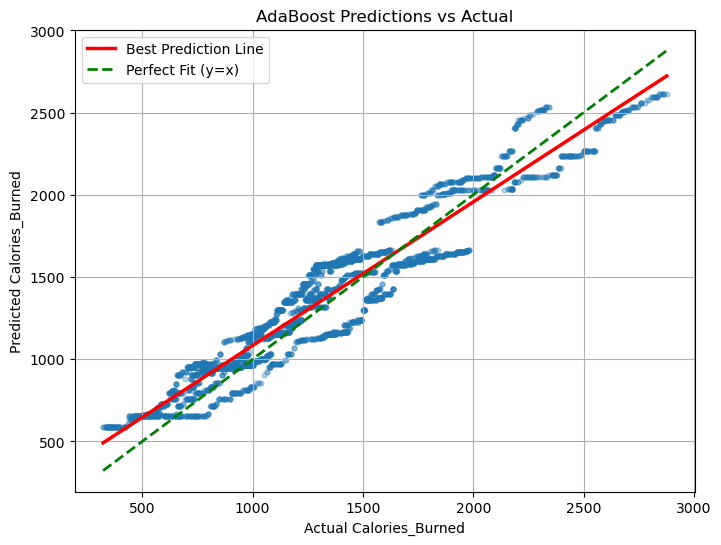

Gradient Boosting Best Params: {'learning_rate': 0.1, 'max_features': 1.0, 'n_estimators': 150}
Gradient Boosting MAE: 9.7425
Gradient Boosting RMSE: 13.1186


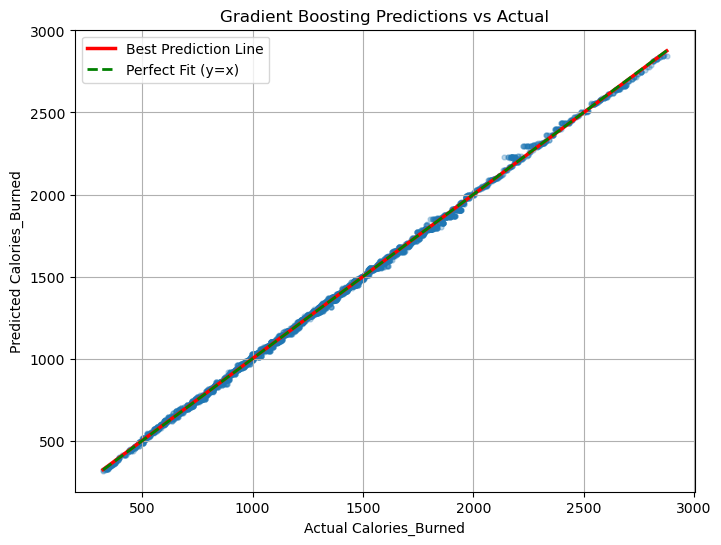

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} RMSE: {rmse:.4f}")

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.3, s=12)

    # Best prediction line
    line_model = LinearRegression()
    line_model.fit(np.array(y_test).reshape(-1,1), np.array(y_pred).reshape(-1,1))
    line_x = np.linspace(min(y_test), max(y_test), 500)
    line_y = line_model.predict(line_x.reshape(-1,1))
    plt.plot(line_x, line_y, color='red', linewidth=2.5, label='Best Prediction Line')

    # Perfect fit
    plt.plot(line_x, line_x, color='green', linestyle='--', linewidth=2, label='Perfect Fit (y=x)')

    plt.xlabel("Actual Calories_Burned")
    plt.ylabel("Predicted Calories_Burned")
    plt.title(f"{model_name} Predictions vs Actual")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Random Forest ---

rf = RandomForestRegressor(random_state=42)
rf_param_grid = {'n_estimators': [50, 100, 150]}
rf_grid = GridSearchCV(rf, rf_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(x_train, y_train)
print("Random Forest Best Params:", rf_grid.best_params_)

# Evaluate using best estimator

evaluate_model(rf_grid.best_estimator_, x_test, y_test, "Random Forest")

# --- AdaBoost ---

ab = AdaBoostRegressor(random_state=42)
ab_param_grid = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 1]}
ab_grid = GridSearchCV(ab, ab_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
ab_grid.fit(x_train, y_train)
print("AdaBoost Best Params:", ab_grid.best_params_)

evaluate_model(ab_grid.best_estimator_, x_test, y_test, "AdaBoost")

# --- Gradient Boosting ---

gb = GradientBoostingRegressor(random_state=42)
gb_param_grid = {'n_estimators': [50, 100, 150], 'learning_rate': [0.01, 0.1, 0.1], 'max_features': [0.5, 0.7, 1.0]}
gb_grid = GridSearchCV(gb, gb_param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
gb_grid.fit(x_train, y_train)
print("Gradient Boosting Best Params:", gb_grid.best_params_)

evaluate_model(gb_grid.best_estimator_, x_test, y_test, "Gradient Boosting")


In [ ]:
#----------------------------------------------------
# FEATURE IMPORTANCE #
#----------------------------------------------------

# If x_train is a DataFrame, get the feature names
feature_names = x_train.columns

# Best models from your GridSearchCV
rf_best = rf_grid.best_estimator_
gb_best = gb_grid.best_estimator_

# --- Random Forest feature importances ---
rf_importances = rf_best.feature_importances_
rf_idx = np.argsort(rf_importances)[::-1]  # sort descending

rf_imp_df = pd.DataFrame({
    "feature": feature_names[rf_idx],
    "importance": rf_importances[rf_idx]
})

print("=== Random Forest - Top 15 Important Features ===")
print(rf_imp_df.head(15))

plt.figure(figsize=(8,6))
plt.barh(rf_imp_df["feature"].head(15)[::-1],
         rf_imp_df["importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (Top 15)")
plt.tight_layout()
plt.show()

# --- Gradient Boosting feature importances ---
gb_importances = gb_best.feature_importances_
gb_idx = np.argsort(gb_importances)[::-1]

gb_imp_df = pd.DataFrame({
    "feature": feature_names[gb_idx],
    "importance": gb_importances[gb_idx]
})

print("=== Gradient Boosting - Top 15 Important Features ===")
print(gb_imp_df.head(15))

plt.figure(figsize=(8,6))
plt.barh(gb_imp_df["feature"].head(15)[::-1],
         gb_imp_df["importance"].head(15)[::-1])
plt.xlabel("Importance")
plt.title("Gradient Boosting Feature Importance (Top 15)")
plt.tight_layout()
plt.show()
